# EDA для проверки актуальности параметра "тип корпуса плёночного фотоаппарата"

Автор: Никита Лосев

В этом ноутбуке я разбираю 49 свежих объявлений из категории "Плёночные фотоаппараты"

## 1. Данные

### 1.1 Откуда выборка

Авито: Главная / Электроника / Фототехника / Пленочные фотоаппараты

Дата сбора: 4 мая 2026

Регион: вся Россия

Всего объявлений в категории на момент сбора: 59 758

Способ сбора: вручную

Я отсортировал выдачу по дате, не ставил дополнительные фильтры и взял первые 49 карточек.

Каждую карточку открывал руками: смотрел заголовок, описание, главное фото и иногда дополнительные фото. Автоматически выгрузить выдачу не получилось, поэтому выборка маленькая. Для первого разбора этого достаточно, для обучения модели - нет.

### 1.2 Файлы

Дальше использую две таблицы: `avito_camera_labels.csv` и `modality_check.csv`.

#### avito_camera_labels.csv

| поле | что записано |
|---|---|
| `row` | номер объявления в ручной разметке, 1-49 |
| `title_short` | короткий заголовок карточки |
| `is_camera` | есть ли камера в объявлении: yes / no / unclear |
| `label` | выбранный класс камеры |
| `conf_1_5` | насколько я уверен в `label`, от 1 до 5 |
| `title_keyword` | есть ли в заголовке прямое слово класса |
| `brand_model_in_title` | есть ли бренд или модель в заголовке |
| `main_photo_enough` | хватает ли главного фото: yes / partial / no |
| `is_hard` | нет прямого класса в заголовке и приходится смотреть фото |
| `comment` | пояснение к спорным или неочевидным случаям |

Для `label` я использовал такие классы:

- `compact_point_and_shoot` - компактная автоматическая камера или одноразовая камера
- `SLR` - зеркальная плёночная камера
- `rangefinder_viewfinder` - дальномерная, шкальная или видоискательная камера
- `TLR` - двухобъективная камера
- `instant` - Polaroid, Instax и другие камеры моментальной печати
- `other_unknown` - лоты, упаковки, не камера или случай вне выбранной схемы

#### modality_check.csv

Отдельно я вынес 8 строк, где было полезно проверить, какая модальность даёт решающий сигнал: фото или текст

- row 6: заголовок просто "Фотоаппарат", в описании Premier PC-661
- row 13: RevueFlex/Chinon, в описании есть "зеркальная"
- row 14: "Зенит ттл", главное фото похоже на чехол, без текста легко промахнуться
- row 24: заголовок "Фотоаппарат", Polaroid видно только дальше
- row 33: заголовок "Фотоаппарат", Konica fx 700, в тексте есть шумная фраза про зарядник
- row 38: Kodak Charmera, по виду скорее коробка/упаковка
- row 43: лот Зенит + Смена, один класс выбрать нельзя
- row 49: Любитель 166, редкий для выборки TLR

В этой таблице я отдельно записал три попытки: только фото, только текст, потом финальную метку по всей карточке.

| поле | что записано |
|---|---|
| `row` | номер объявления из основной таблицы |
| `label_photo_only` | что получилось определить только по фото, без заголовка и описания |
| `conf_photo_only` | уверенность в фото-версии, 1-5 |
| `label_text_only` | что получилось определить только по заголовку и описанию, без фото |
| `conf_text_only` | уверенность в текстовой версии, 1-5 |
| `label_full` | финальная метка после просмотра всей карточки |
| `winning_modality` | откуда реально пришел ответ: photo / text / both / neither |
| `note` | почему строка попала в этот мини-тест |

## 2. Быстрая проверка таблиц

### 2.1 Пустые значения

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_dir = Path(".")
if not (data_dir / "avito_camera_labels.csv").exists():
    data_dir = Path("../data")

df = pd.read_csv(data_dir / "avito_camera_labels.csv", encoding="utf-8-sig")
modality = pd.read_csv(data_dir / "modality_check.csv", encoding="utf-8-sig")

print(f"основная таблица: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"modality: {modality.shape[0]} строк, {modality.shape[1]} колонок")

основная таблица: 49 строк, 10 колонок
modality: 8 строк, 8 колонок


In [86]:
df.isna().sum()

row                     0
title_short             0
is_camera               0
label                   0
conf_1_5                0
title_keyword           0
brand_model_in_title    0
main_photo_enough       0
is_hard                 0
comment                 9
dtype: int64

In [87]:
empty = df.select_dtypes("object").apply(lambda s: s.fillna("").str.strip().eq("").sum())
empty

/var/folders/d0/7qx0w2p176zg3q_4h0b3c81c0000gn/T/ipykernel_31500/609339251.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  empty = df.select_dtypes("object").apply(lambda s: s.fillna("").str.strip().eq("").sum())


title_short             0
is_camera               0
label                   0
title_keyword           0
brand_model_in_title    0
main_photo_enough       0
is_hard                 0
comment                 9
dtype: int64

Пустых мест почти нет. В `comment` 9 пустых строк - там просто нечего было дописать. Остальные поля заполнены.

### 2.2 Повторы

In [88]:
print(f"полные дубли строк: {df.duplicated().sum()}")
print(f"дубли по row: {df['row'].duplicated().sum()}")

полные дубли строк: 0
дубли по row: 0


In [89]:
same_titles = df[df["title_short"].duplicated(keep=False)].sort_values("title_short")
same_titles[["row", "title_short", "label"]]

,row,title_short,label
5,6,Фотоаппарат,compact_point_and_shoot
23,24,Фотоаппарат,instant
32,33,Фотоаппарат,compact_point_and_shoot
29,30,Фотоаппарат Olympus trip 505,compact_point_and_shoot
34,35,Фотоаппарат Olympus trip 505,compact_point_and_shoot


Полных дублей нет, `row` не повторяется.

Одинаковые короткие заголовки есть: 3 раза "Фотоаппарат" и 2 раза "Фотоаппарат Olympus trip 505". Это разные карточки, а не дубли. С "Фотоаппарат" по заголовку вообще ничего не понять: в выборке под ним есть и compact, и instant.

### 2.3 Значения в колонках

In [90]:
class_values = {
    "compact_point_and_shoot",
    "SLR",
    "rangefinder_viewfinder",
    "TLR",
    "instant",
    "other_unknown",
}

allowed_main = {
    "is_camera": {"yes", "no", "unclear"},
    "label": class_values,
    "title_keyword": {"yes", "no"},
    "brand_model_in_title": {"yes", "no"},
    "main_photo_enough": {"yes", "partial", "no"},
    "is_hard": {"yes", "no"},
    "conf_1_5": {1, 2, 3, 4, 5},
}

allowed_modality = {
    "label_photo_only": class_values,
    "label_text_only": class_values,
    "label_full": class_values,
    "winning_modality": {"photo", "text", "both", "neither"},
    "conf_photo_only": {1, 2, 3, 4, 5},
    "conf_text_only": {1, 2, 3, 4, 5},
}

In [91]:
for name, table, rules in [
    ("avito_camera_labels.csv", df, allowed_main),
    ("modality_check.csv", modality, allowed_modality),
]:
    print(name)
    found = False
    for col, ok in rules.items():
        bad = set(table[col].unique()) - ok
        if bad:
            found = True
            print(f"  {col}: {bad}")
    if not found:
        print("  ок")

avito_camera_labels.csv
  ок
modality_check.csv
  ок


In [92]:
print(f"row: {df['row'].min()}-{df['row'].max()}")
print(f"уникальных row: {df['row'].nunique()} из {len(df)}")

row: 1-49
уникальных row: 49 из 49


В категориальных колонках лишних значений нет. `row` идет от 1 до 49, пропусков и дублей по нему нет.

### 2.4 Уверенность в ручной разметке

In [93]:
conf_dist = df["conf_1_5"].value_counts().sort_index()
print(conf_dist)
print(f"\nсредняя уверенность: {df['conf_1_5'].mean():.2f}")

conf_1_5
2     1
3     1
4     7
5    40
Name: count, dtype: int64

средняя уверенность: 4.76


In [94]:
df["is_hard"].value_counts()

is_hard
yes    33
no     16
Name: count, dtype: int64

In [95]:
df.groupby("is_hard")["conf_1_5"].agg(["mean", "min", "max", "count"])

,mean,min,max,count
is_hard,,,,
no,4.625000,2,5,16
yes,4.818182,3,5,33


40 строк с conf=5, еще 7 с conf=4. Низкая уверенность только в двух строках.

Важно: `is_hard` здесь означает не низкую уверенность разметчика, а отсутствие прямого класса в заголовке. Поэтому у `is_hard=yes` средняя уверенность может быть высокой: сложность не в ручной разметке, а в том, что одного заголовка часто недостаточно.

In [96]:
photo_match_full = (modality["label_photo_only"] == modality["label_full"]).sum()
text_match_full = (modality["label_text_only"] == modality["label_full"]).sum()
photo_match_text = (modality["label_photo_only"] == modality["label_text_only"]).sum()

print(f"фото = финал: {photo_match_full}/{len(modality)}")
print(f"текст = финал: {text_match_full}/{len(modality)}")
print(f"фото = текст:  {photo_match_text}/{len(modality)}")

фото = финал: 7/8
текст = финал: 6/8
фото = текст:  5/8


In [97]:
disagree = modality[modality["label_photo_only"] != modality["label_text_only"]]
disagree[["row", "label_photo_only", "label_text_only", "label_full", "winning_modality", "note"]]

,row,label_photo_only,label_text_only,label_full,winning_modality,note
0,6,compact_point_and_shoot,other_unknown,compact_point_and_shoot,photo,"На фото обычная compact. В тексте только ""Prem..."
2,14,other_unknown,SLR,SLR,text,"Главное фото похоже на чехол, без текста класс..."
4,33,compact_point_and_shoot,other_unknown,compact_point_and_shoot,photo,"Текст сбивает из-за ""зарядник утерян"". По фото..."


In [98]:
modality["winning_modality"].value_counts()

winning_modality
photo      3
both       3
text       1
neither    1
Name: count, dtype: int64

На этих 8 строках фото совпало с финальной меткой в 7 случаях, текст - в 6.

Разошлись они в row 6, 14 и 33:

- row 6: текст не дает класса, фото дает compact
- row 14: главное фото/чехол путает, текст "Зенит ттл" вытаскивает SLR
- row 33: текст уводит в `other_unknown`, фото больше похоже на compact, но я оставил низкую уверенность в основной таблице

`winning_modality`: both 3, photo 3, text 1, neither 1.

Вывод по этой мини-проверке: фото часто даёт полезный сигнал, но текст нельзя игнорировать. Также нужен отказ от автозаполнения, потому что упаковки и смешанные лоты не стоит принудительно относить к одному классу.

## 3. Что лежит в выборке

### 3.1 Метка класса

In [99]:
label_counts = df["label"].value_counts()
label_counts

label
compact_point_and_shoot    15
SLR                        10
instant                    10
rangefinder_viewfinder      7
other_unknown               6
TLR                         1
Name: count, dtype: int64

In [100]:
camera_rows = df[df["is_camera"].eq("yes") & df["label"].ne("other_unknown")]
counts = camera_rows["label"].value_counts()

top_class = counts.idxmax()
rare_class = counts.idxmin()
ratio = counts.max() / counts.min()

print(f"размечаемых камер, без other_unknown: {len(camera_rows)}")
print(f"самый частый класс: {top_class} = {counts.max()}")
print(f"самый редкий класс: {rare_class} = {counts.min()}")
print(f"перекос: {ratio:.0f}x")

размечаемых камер, без other_unknown: 43
самый частый класс: compact_point_and_shoot = 15
самый редкий класс: TLR = 1
перекос: 15x


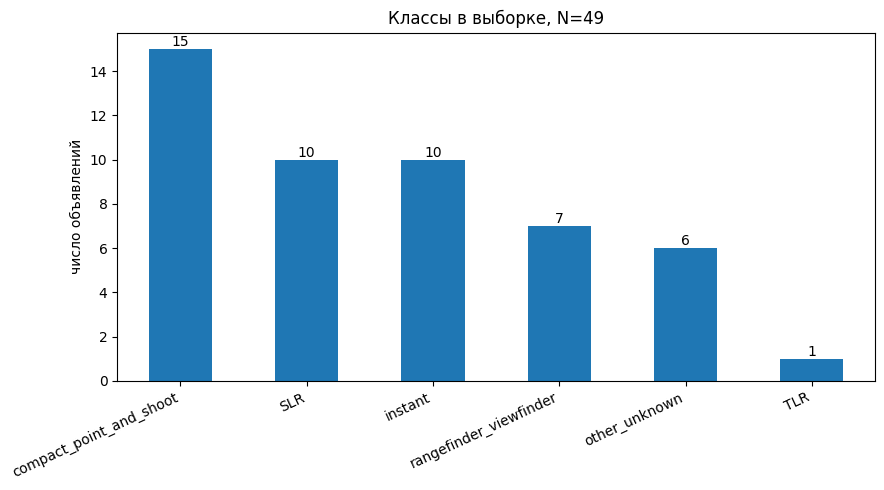

In [101]:
fig, ax = plt.subplots(figsize=(9, 5))
label_counts.plot(kind="bar", ax=ax)
ax.set_title("Классы в выборке, N=49")
ax.set_ylabel("число объявлений")
ax.set_xlabel("")
ax.bar_label(ax.containers[0])
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Главный перекос - compact 15 против TLR 1. `other_unknown` это не класс камеры, туда попали лоты, упаковки и штуки вне моей схемы.

Для обучения так оставлять нельзя: TLR почти наверняка потеряется при обычном train/test split. Нужно отдельно добрать редкие классы или хотя бы учитывать веса классов.

"Всегда compact" дает 15/49, то есть около 31%. Это нижняя планка, с которой можно сравнивать первые правила.

### 3.2 Сигналы из заголовка и фото

Проверил четыре простых признака: есть ли слово класса в заголовке, есть ли бренд/модель, хватает ли главного фото, попала ли строка в `is_hard`.

In [102]:
binary_cols = ["title_keyword", "brand_model_in_title", "main_photo_enough", "is_hard"]

rows = []
for col in binary_cols:
    counts = df[col].value_counts()
    for val, cnt in counts.items():
        rows.append({
            "колонка": col,
            "значение": val,
            "штук": cnt,
            "доля": f"{cnt / len(df):.1%}",
        })

pd.DataFrame(rows)

,колонка,значение,штук,доля
0,title_keyword,no,42,85.7%
1,title_keyword,yes,7,14.3%
2,brand_model_in_title,yes,45,91.8%
3,brand_model_in_title,no,4,8.2%
4,main_photo_enough,yes,38,77.6%
5,main_photo_enough,partial,7,14.3%
6,main_photo_enough,no,4,8.2%
7,is_hard,yes,33,67.3%
8,is_hard,no,16,32.7%


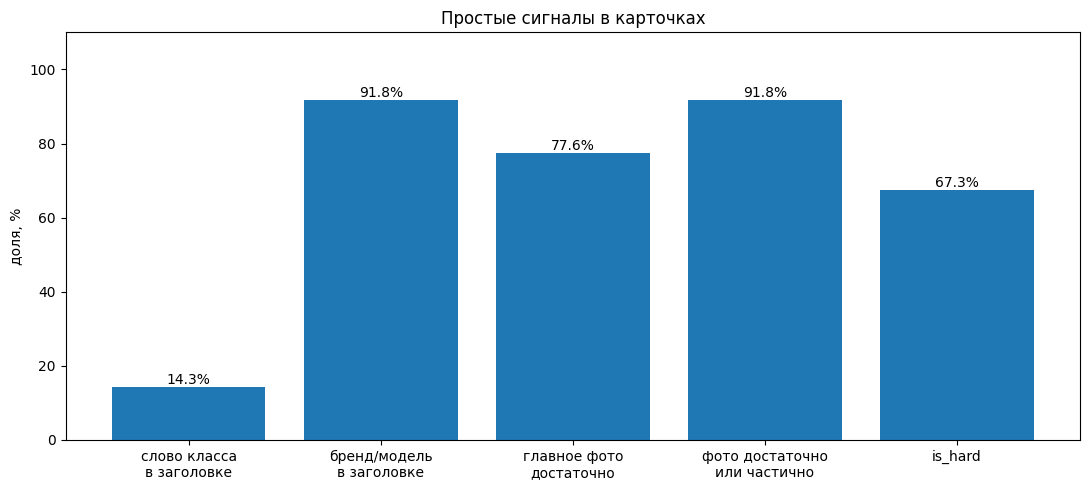

In [103]:
signals = {
    "слово класса\nв заголовке": df["title_keyword"].eq("yes").sum(),
    "бренд/модель\nв заголовке": df["brand_model_in_title"].eq("yes").sum(),
    "главное фото\nдостаточно": df["main_photo_enough"].eq("yes").sum(),
    "фото достаточно\nили частично": df["main_photo_enough"].isin(["yes", "partial"]).sum(),
    "is_hard": df["is_hard"].eq("yes").sum(),
}

labels = list(signals.keys())
values = [100 * v / len(df) for v in signals.values()]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, values)
ax.set_title("Простые сигналы в карточках")
ax.set_ylabel("доля, %")
ax.set_ylim(0, 110)
ax.bar_label(bars, fmt="%.1f%%")
plt.tight_layout()
plt.show()

Что получилось:

- слово класса в заголовке есть только в 7 из 49
- бренд или модель есть в 45 из 49
- главное фото само по себе хватает в 38 из 49
- если считать "частично", фото помогает в 45 из 49
- `is_hard=yes` у 33 строк

Поэтому регулярки по словам типа "зеркалка", "мыльница", "Polaroid" почти бесполезны как основной способ. Словарь модель камеры -> тип корпуса выглядит сильнее, но 45/49 тут не надо читать как готовое качество: модель еще надо нормально вытащить из грязного заголовка.

Фото отдельно тоже не закрывает всё: мешают чехлы, коробки, плохие ракурсы и лоты из нескольких товаров.

### 3.3 Пары признаков

Тут смотрю не новые метрики, а где именно ломаются простые правила.

In [104]:
class_order = [
    "compact_point_and_shoot",
    "SLR",
    "instant",
    "rangefinder_viewfinder",
    "TLR",
    "other_unknown",
]

ct_photo = pd.crosstab(df["label"], df["main_photo_enough"])
ct_photo = ct_photo.reindex(class_order, fill_value=0)[["yes", "partial", "no"]]
ct_photo

main_photo_enough,yes,partial,no
label,,,
compact_point_and_shoot,14,1,0
SLR,8,1,1
instant,7,3,0
rangefinder_viewfinder,5,0,2
TLR,1,0,0
other_unknown,3,2,1


По фото хуже всего видны `rangefinder_viewfinder` и `instant`: часто мешают чехлы, коробки или плохой ракурс.

У `SLR` один явный проблемный случай - row 14, где главное фото похоже на чехол. `compact_point_and_shoot` почти всегда видно сразу.

In [105]:
ct_hard_conf = pd.crosstab(df["is_hard"], df["conf_1_5"])
ct_hard_conf

conf_1_5,2,3,4,5
is_hard,,,,
no,1,0,3,12
yes,0,1,4,28


`is_hard=yes` не означает низкую уверенность разметки. В этой группе 28 строк с `conf_1_5 = 5` и нет строк с `conf_1_5 = 2`.

То есть название "hard" немного кривое: это не "мне было сложно", а "в заголовке нет прямого класса, надо смотреть картинку".

In [106]:
ct_brand = pd.crosstab(df["label"], df["brand_model_in_title"])
ct_brand = ct_brand.reindex(class_order, fill_value=0)[["yes", "no"]]
ct_brand

brand_model_in_title,yes,no
label,,
compact_point_and_shoot,13,2
SLR,10,0
instant,9,1
rangefinder_viewfinder,7,0
TLR,1,0
other_unknown,5,1


У `SLR` и `rangefinder_viewfinder` бренд/модель есть в каждом заголовке. У compact не всегда: два объявления называются просто "Фотоаппарат".

Вывод для текущего этапа: справочник моделей выглядит сильным простым решением, но не закрывает все случаи. В спорных карточках важен отказ от автозаполнения: для `other_unknown` оба сигнала часто слабые, поэтому принудительно выбирать класс рискованно.

## 4. Насколько этой выборке можно верить

Всего в категории было 59 758 объявлений, я взял 49. Это примерно 0.08% от категории.

Отбор: первые строки после сортировки по дате, без фильтров по цене, состоянию или региону. Это свежая выдача на 4 мая 2026, а не случайная выборка.

Главное смещение - свежесть. В выборку попали объявления, которые появились недавно. То, что висит месяцами, здесь почти не видно.

Еще есть перекос по активности продавцов: кто чаще перевыкладывает товар, тот чаще попадает в верх выдачи. Регион тоже не контролировался, стояла вся Россия.

Также разметчик был один. Для первичной проверки этого достаточно, но для финальных выводов о качестве модели — мало.

Числа из этого ноутбука я использую как ориентир.

Например, 45/49 заголовков с брендом или моделью значит только "в этой свежей выдаче бренды часто написаны". Это не значит, что словарь моделей сразу даст 92% качества на всей категории.

Что можно использовать как выводы текущего этапа:

- параметр в большинстве случаев можно разметить вручную
- прямые слова класса в заголовке дают низкое покрытие
- фото часто даёт сигнал о типе корпуса
- редкие классы в текущем срезе представлены слабо

Чего нельзя делать: выдавать проценты из 49 карточек как точную статистику всей категории или как доказанный экономический эффект. Их можно использовать только как прикидочную оценку для принятия решения.

## 5. Фото против текста на 8 спорных строках

In [107]:
n = len(modality)
photo_acc = (modality["label_photo_only"] == modality["label_full"]).mean()
text_acc = (modality["label_text_only"] == modality["label_full"]).mean()

print(f"только фото:  {photo_acc:.0%}  ({int(photo_acc*n)}/{n})")
print(f"только текст: {text_acc:.0%}  ({int(text_acc*n)}/{n})")

только фото:  88%  (7/8)
только текст: 75%  (6/8)


In [108]:
mean_conf_photo = modality["conf_photo_only"].mean()
mean_conf_text = modality["conf_text_only"].mean()

print(f"средний conf по фото:  {mean_conf_photo:.2f} / 5")
print(f"средний conf по тексту: {mean_conf_text:.2f} / 5")

средний conf по фото:  4.00 / 5
средний conf по тексту: 3.25 / 5


В мини-проверке на 8 спорных строках: фото совпало с финальной меткой в 7/8 случаев, текст - в 6/8.

Средняя уверенность: фото 4.00, текст 3.25. Разница есть, но в этих строках важнее другое: фото чаще дает рабочий сигнал, а текст иногда спасает от ошибки.

In [109]:
disagree = modality[modality["label_photo_only"] != modality["label_text_only"]]
disagree[[
    "row",
    "label_photo_only", "conf_photo_only",
    "label_text_only", "conf_text_only",
    "label_full", "winning_modality", "note",
]]

,row,label_photo_only,conf_photo_only,label_text_only,conf_text_only,label_full,winning_modality,note
0,6,compact_point_and_shoot,5,other_unknown,2,compact_point_and_shoot,photo,"На фото обычная compact. В тексте только ""Prem..."
2,14,other_unknown,2,SLR,4,SLR,text,"Главное фото похоже на чехол, без текста класс..."
4,33,compact_point_and_shoot,4,other_unknown,2,compact_point_and_shoot,photo,"Текст сбивает из-за ""зарядник утерян"". По фото..."


Три строки, где фото и текст не сошлись:

row 6 - текст почти пустой, фото дает compact

row 14 - главное фото не помогает, текст "Зенит ттл" дает SLR

row 33 - текст странный из-за "зарядник утерян", по фото оставил compact, но с низкой уверенностью в основной таблице

То есть текст не надо выкидывать, потому что в отдельных случаях он исправляет ошибку, возникающую по фото.

In [110]:
modality["winning_modality"].value_counts()

winning_modality
photo      3
both       3
text       1
neither    1
Name: count, dtype: int64

`both`: row 13, 24, 43

`photo`: row 6, 33, 49

`text`: row 14

`neither`: row 38

Row 38 как раз пример, где лучше вернуть `other_unknown`, а не выбирать класс наугад.

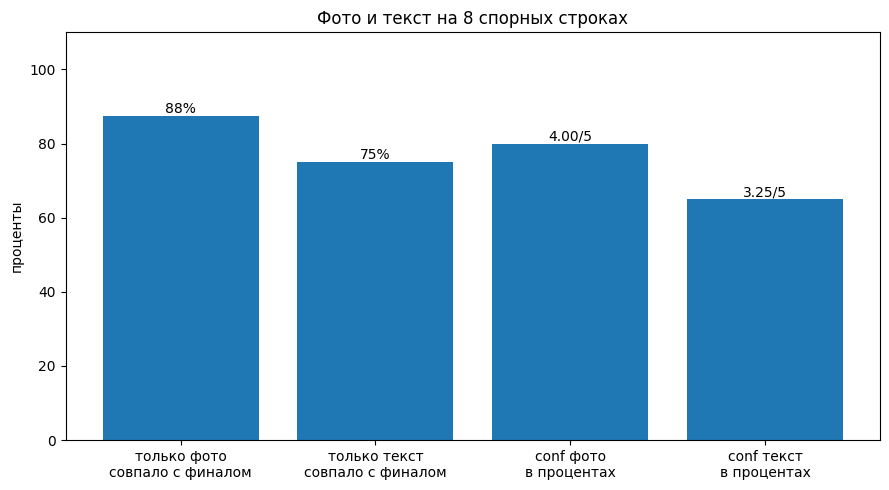

In [111]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = [
    "только фото\nсовпало с финалом",
    "только текст\nсовпало с финалом",
    "conf фото\nв процентах",
    "conf текст\nв процентах",
]
values = [100 * photo_acc, 100 * text_acc, 20 * mean_conf_photo, 20 * mean_conf_text]
bars = ax.bar(labels, values)
ax.set_title("Фото и текст на 8 спорных строках")
ax.set_ylabel("проценты")
ax.set_ylim(0, 110)
ax.bar_label(bars, labels=[
    f"{photo_acc:.0%}",
    f"{text_acc:.0%}",
    f"{mean_conf_photo:.2f}/5",
    f"{mean_conf_text:.2f}/5",
])
plt.tight_layout()
plt.show()

На этих 8 строках фото чаще совпадает с финальной меткой, но этого недостаточно, чтобы делать вывод в пользу подхода только по фото.

Главный контрпример - row 14: чехол на главном фото, а текст с моделью дает SLR. Обратный пример - row 6, где заголовок пустой, а камера на фото читается сразу.

Для текущего этапа отсюда достаточно вывода: будущему решению понадобится возможность отказа, потому что `other_unknown` и лоты нельзя безопасно принудительно относить к одному из типов корпуса.

## 6. Что я беру из этого разбора

Коротко:

- категорию сначала надо чистить от не-камер, но таких строк в этой выборке мало
- тип корпуса в большинстве карточек можно разметить вручную
- сильный перекос по классам: compact много, TLR почти нет
- слова класса в заголовке почти не работают
- бренд или модель в заголовке часто есть, но это ещё не готовое качество справочника
- фото часто даёт сигнал о типе корпуса, кроме случаев с чехлами, коробками и плохим ракурсом
- текст полезен как дополнительный источник сигнала
- для спорных строк нужен отказ: `other_unknown`, а не угадывание

Для текущего этапа главный вывод такой: простое решение через справочник обязательно нужно рассматривать как бейзлайн, но в данных есть случаи, где одного текста недостаточно и нужен сигнал из фото или отказ.

### 6.1 Ограничения выводов

Этот ноутбук не задаёт план обучения модели. Его задача - проверить, есть ли в категории наблюдаемый параметр, насколько часто он встречается в ручном срезе и закрывается ли он простыми правилами.

Поэтому выводы ниже нельзя читать как финальные метрики или как готовую схему решения. Они нужны только для решения актуальности проблемы проекта.

### 6.2 Что нельзя утверждать по этому срезу

- нельзя считать поиск слов "зеркалка»/«мыльница" достаточным решением: покрытие слишком низкое
- нельзя делать общий вывод, что фото всегда достаточно: row 14 показывает обратный случай
- нельзя делать общий вывод, что текста всегда достаточно: row 6 и row 33 показывают обратные случаи
- нельзя читать проценты из этого ноутбука как финальные метрики качества

### 6.3 Вывод

Идея выглядит реалистичной для дальнейшей проверки. По карточкам часто можно понять тип камеры, причём фото и текст дополняют друг друга.

Но эта выборка не даёт финальных процентов качества. Она показывает только то, что задачу имеет смысл проверять дальше на более репрезентативных данных.

## 7. Ограничения

49 объявлений - маленькая ручная выборка, а не статистика по Авито.

Отбор был по свежей выдаче, без случайности и без стратификации. Разметчик один. Проверка модальностей сделана всего на 8 специально выбранных строках.

Поэтому все проценты здесь читаю как подсказки для следующего шага.